In [1]:
from algs.cd_poly import *

import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from functools import partial

np.random.seed(0)

## Gaussian example

In [11]:
mu = np.full((2,), .5)
sig = np.array([[1., .5,], [.5, 1.]])

z = multivariate_normal(mu, sig).rvs(1000)

[fit_cd] X shape=(1000, 6), M cond=4.920299e+01, method=qr, eps=0.0


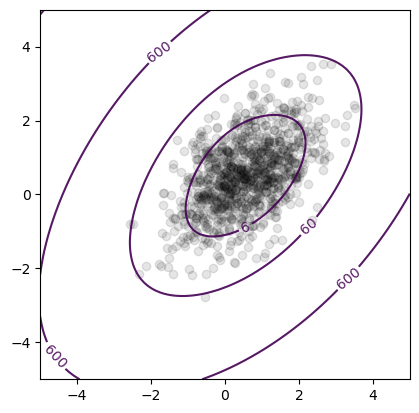

In [17]:
p = CDPolynomial(z, degree=2, method='qr', verbose=True)

fig, ax = plt.subplots()
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
p.plot(ax)
ax.scatter(*z.T, color='black', alpha=0.1)
ax.set_aspect('equal')

In [19]:
sample_vals = p(z)
sample_vals.mean(), p.n_monomials # these should be almost equal, according to Lemma 3

AttributeError: 'CDPolynomial' object has no attribute 'n_monomials'

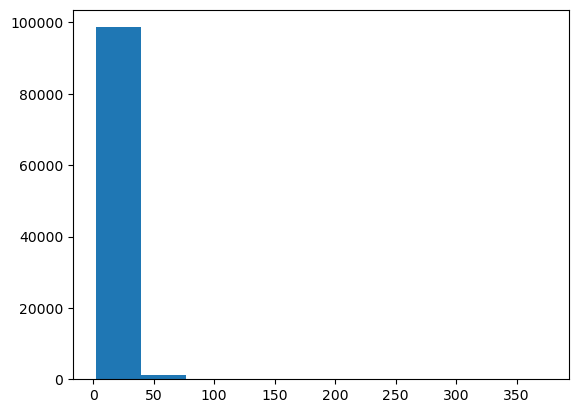

In [107]:
plt.hist(sample_vals);

In [108]:
idx_max = np.argmax(sample_vals)
print(f'Sample point with most extreme CD poly value: {z[idx_max]}')

Sample point with most extreme CD poly value: [3.73066146 5.67345284]


In [109]:
quantiles = [np.quantile(sample_vals, q=q) for q in [0., .25, .5, .75, 1.]]
quantiles

[np.float64(1.9929391484237908),
 np.float64(2.1630877756306672),
 np.float64(2.9522720650493093),
 np.float64(5.812495702118669),
 np.float64(374.61607400133437)]

## Number of samples vs. total degree

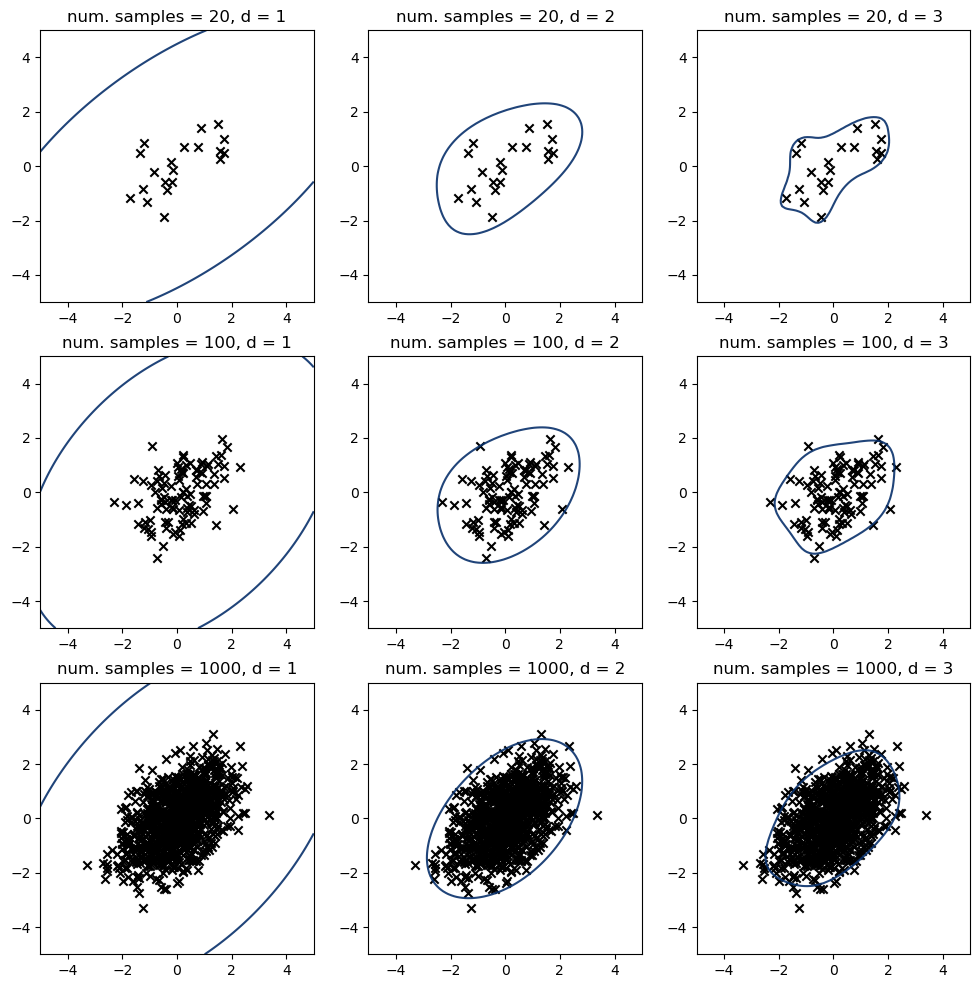

In [110]:
lim = 5
ns = [20, 100, 1_000]
ds = [1, 2, 3]

fig, axs = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    z = multivariate_normal([0., 0.], [[1., .5], [.5, 1.]]).rvs(ns[i])
    for j in range(3):
        p = CDPolynomial(z, degree=ds[j])
        ax = axs[i, j]
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        plot_level_set(p, 40., ax)
        ax.scatter(*z.T, color='black', marker='x')
        ax.set_title(f'num. samples = {ns[i]}, d = {ds[j]}')

## Degree vs. Cutoff hyperparam

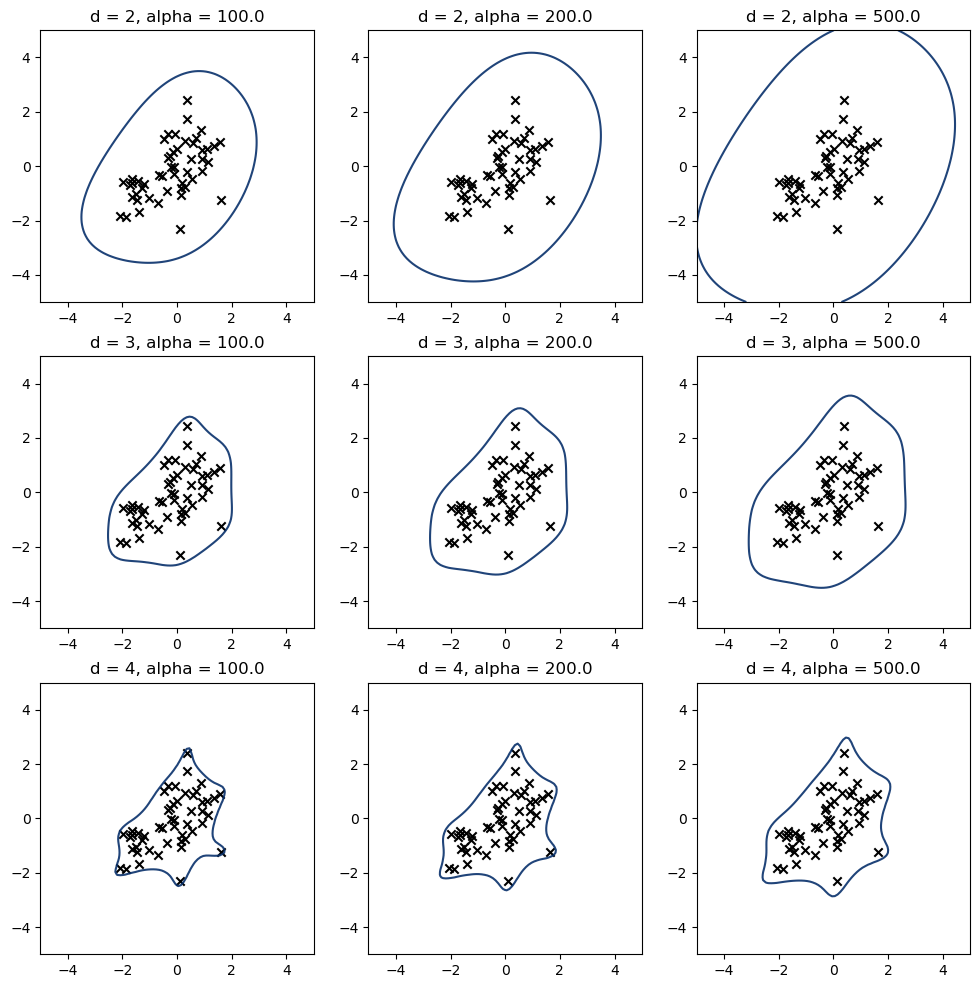

In [111]:
lim = 5
ds = [2, 3, 4]
cuts = [100., 200., 500.]

fig, axs = plt.subplots(3, 3, figsize=(12, 12))

z = multivariate_normal([0., 0.], [[1., .5], [.5, 1.]]).rvs(50)
for i in range(3):
    for j in range(3):
        p = CDPolynomial(z, degree=ds[i])
        ax = axs[i, j]
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        plot_level_set(p, cuts[j], ax)
        ax.scatter(*z.T, color='black', marker='x')
        ax.set_title(f'd = {ds[i]}, alpha = {cuts[j]}')

## Extending to the infinite-dimensional case: Chebyshev basis

In [112]:
from scipy.special import eval_chebyt

class Chebyshev():
    """
    A function represented by coordinates in the Chebyshev basis.
    """

    def __init__(self, coords):
        self.n_basis = len(coords)
        self.coords = coords

    def __call__(self, z):
        """
        Evaluate the function represented by these coordinates at z. Vectorized over z.
        """
        proj = np.column_stack([eval_chebyt(k, z) for k in range(self.n_basis)])
        return  proj @ self.coords
    
    def __add__(self, other):
        return Chebyshev(self.coords + other.coords)

In [113]:
const = 1 / 3
g0 = Chebyshev(np.array([0., const, const, const])) # reference function

In [114]:
def sample_funcs(n_funcs, noise=.1):
    "Sample functions on [-1, 1] using the Chebyshev basis."
    coords = sample_ball_unif(n_funcs, noise, dim=4)
    funcs = [g0 + Chebyshev(coord) for coord in coords]
    return funcs

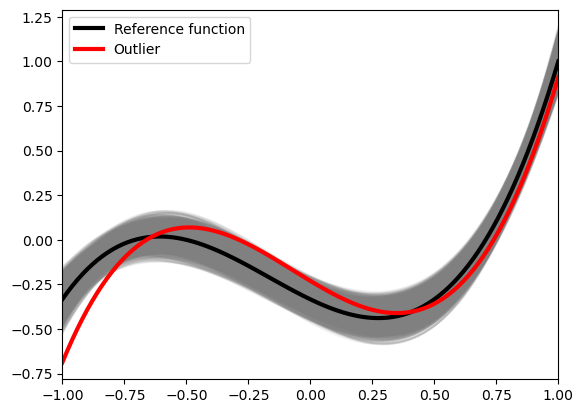

In [115]:
fig, ax = plt.subplots()

gs = sample_funcs(1_000)
for g in gs:
    plot_func(g, ax, color='grey', alpha=.1)

plot_func(g0, ax, label='Reference function', lw=3, color='black')

g_outlier = sample_funcs(1, noise=.2)[0]
plot_func(g_outlier, ax, label='Outlier', lw=3, color='red')

ax.set_xlim(-1, 1)
ax.legend()

In [116]:
gs_coords = np.stack([g.coords for g in gs])

p = CDPolynomial(gs_coords, degree=4, eps=0.)

In [117]:
p.n_vars, p.n_monomials

(4, 70)

In [118]:
sample_vals = p(gs_coords)

sample_vals.max()

np.float64(234.71279350896967)

In [119]:
# should be about equal, according to Lemma 3
# this will only be the case if the regularization param eps is set to zero
sample_vals.mean(), p.n_monomials 

(np.float64(69.9999999999993), 70)

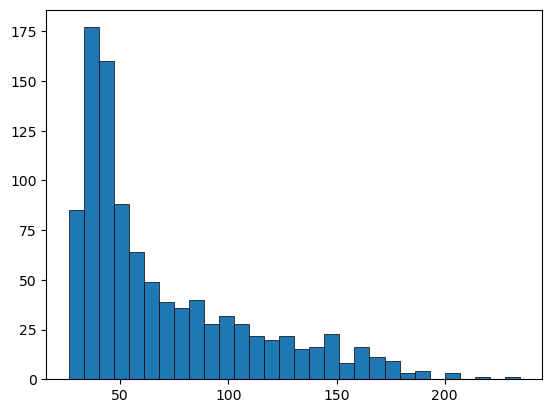

In [120]:
plt.hist(sample_vals, bins=30, edgecolor='black', lw=.5);

In [121]:
p(np.array([g_outlier.coords])) # as expected, much larger than for the sampled functions

array([182624.16129866])

## Gaussian mixture example

In [122]:
n = 100_000

mu1 = np.array([0, 0])
sig1 = np.array([[1., 0.,], [0., 1.]])
z1 = multivariate_normal(mu1, sig1).rvs(n // 2)

sig2 = np.array([[4., 0.,], [0., .2]])
z2 = multivariate_normal(mu2, sig2).rvs(n // 2)

mu3 = np.array([2., 3.])
sig3 = np.array([[.9, .5,], [.5, .9]])
z3 = multivariate_normal(mu3, sig3).rvs(n // 2)

z = np.concatenate([z1, z2])

NameError: name 'mu2' is not defined

In [123]:
z = multivariate_normal(mu1, sig1).rvs(n)

In [124]:
q = np.quantile(1 / p(z), q=0.99)

ValueError: shapes of a (70, 70) and b (15, 100000) are incompatible

Data monomials shape: (100000, 171)
Moment matrix cond num: 4.469291e+20
Empirical mean of CD poly: 171.00000000000452
100000 17


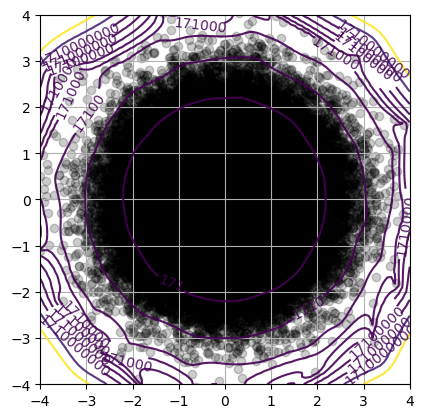

In [125]:
d = int(n ** (1/4))
p = CDPolynomial(z, degree=d, verbose=True)
print(n, d)

#q = np.quantile(p(z), q=0.9)
#print(q)

fig, ax = plt.subplots()
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
p.plot(ax)
#plot_level_set(p, q, plt.gca())
ax.scatter(*z.T, color='black', alpha=.2)
ax.set_aspect('equal')
plt.grid()

## Algebraic regions

In [126]:
def sample_astroid(n):
    samples = []
    count = 0
    while len(samples) < n:
        # Sample in bounding box [-1, 1] x [-1, 1]
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)

        # Check if inside the astroid
        if (abs(x)**(2/3) + abs(y)**(2/3)) <= 1:
            samples.append((x, y))
        
        count += 1  # Track how many total points tested
    
    samples = np.array(samples)
    return samples

Data monomials shape: (10000, 66)
Moment matrix cond num: 1.509069e+13
Empirical mean of CD poly: 65.99999999990017
10000 10


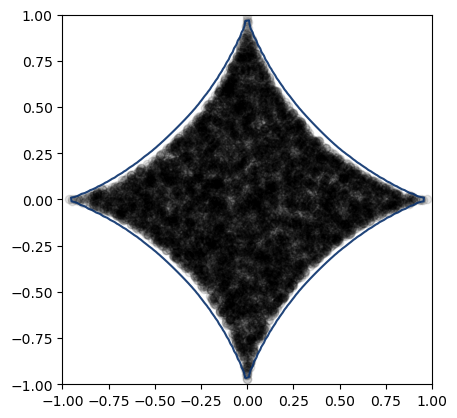

In [127]:
n = 1_0000
z = sample_astroid(n)
d = int(n ** (1/4))
p = CDPolynomial(z, degree=d, verbose=True, method='chol')
print(n, d)

fig, ax = plt.subplots()
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
#p.plot(ax)
plot_level_set(p, p(z).max(), ax=plt.gca())
ax.scatter(*z.T, color='black', alpha=.1)
ax.set_aspect('equal')

## Graph of CD poly in 1 dimension

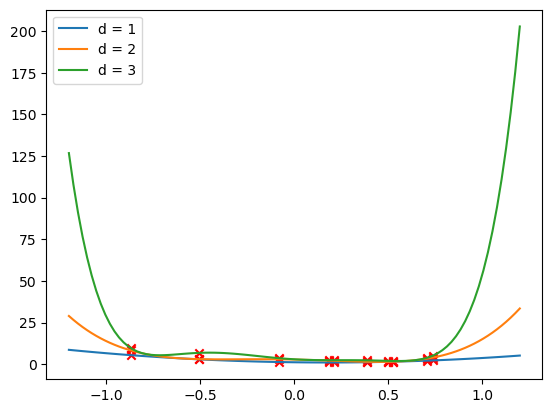

In [102]:
z = 2 * np.random.rand(10)[:, np.newaxis] - 1  # U[-1, 1]

for d in [1, 2, 3]:
    p = CDPolynomial(z, degree=d)

    xlim = 1.2
    t = np.linspace(-xlim, xlim, 100)[:, np.newaxis]
    plt.scatter(z, p(z), marker='x', color='red')
    plt.plot(t, p(t), label=f'd = {d}')
    plt.legend()